In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import plotly as px

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error



In [69]:
df = pd.read_csv('Resources/Tema_9.csv',encoding='latin1', delimiter=';')

In [70]:
print(f"\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print("\n Primeras 5 filas:")
df.head(5)




Dimensiones del dataset: 10000 filas x 22 columnas

 Primeras 5 filas:


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [71]:
print("\nInformación de columnas:")
print(df.info())

print("\nTipos de datos por columna:")
print(df.dtypes)




Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-n

In [72]:
print("\nEstadísticas descriptivas (variables númericas):")
df.describe()


Estadísticas descriptivas (variables númericas):


,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,1.000000e+04,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,5.623396e+09,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,7.021025e+07,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,5.509248e+09,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,5.668610e+09,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,5.668626e+09,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,5.668663e+09,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [73]:
print("\nEstadísticas descriptivas (variables categóricas):")
df.describe(include=['object'])


Estadísticas descriptivas (variables categóricas):


,category,title,body,amenities,currency,fee,has_photo,pets_allowed,price_display,price_type,address,cityname,state,source
count,10000,10000,10000,6451,10000,10000,10000,5837,10000,10000,6673,9923,9923,10000
unique,3,9350,9961,2254,1,1,3,3,1726,3,6658,1574,51,12
top,housing/rent/apartment,Apartment in great location,"When searching for a pet-friendly One-, Two- a...",Parking,USD,No,Thumbnail,"Cats,Dogs","$1,350",Monthly,908 8th SW St,Austin,TX,RentLingo
freq,9996,40,6,229,10000,10000,8907,5228,86,9998,3,523,1737,6912


              Cantidad  Porcentaje
pets_allowed      4163       41.63
amenities         3549       35.49
address           3327       33.27
cityname            77        0.77
state               77        0.77
bathrooms           34        0.34
latitude            10        0.10
longitude           10        0.10
bedrooms             7        0.07


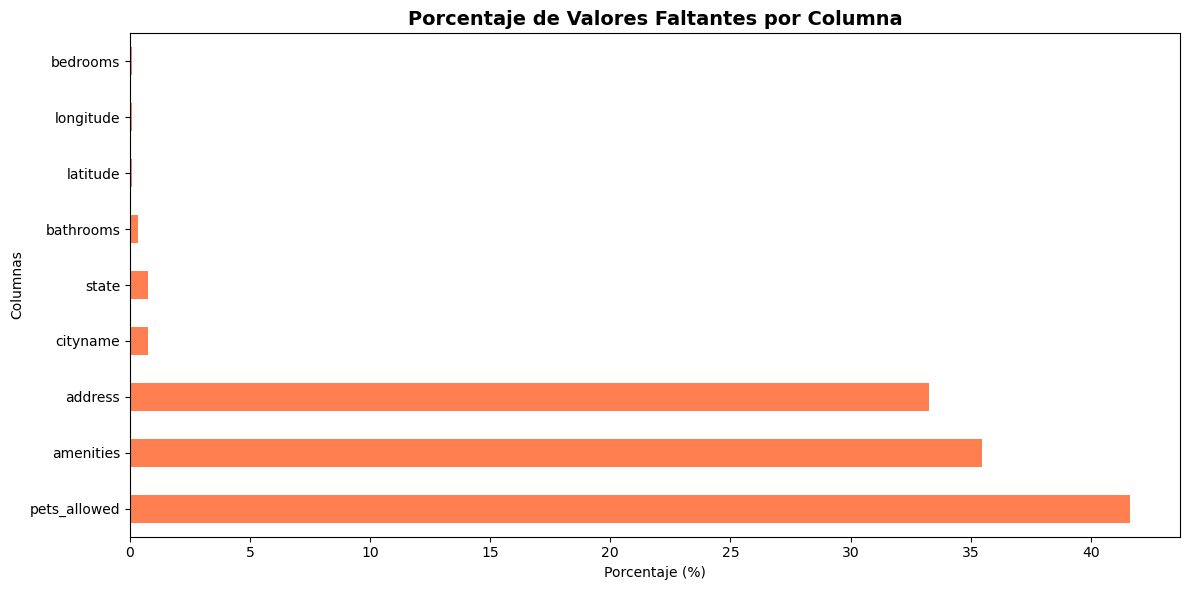

In [74]:
missing_data = pd.DataFrame({
    'Cantidad': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Cantidad'] > 0].sort_values('Cantidad', ascending=False)
print(missing_data)
if not missing_data.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_data['Porcentaje'].plot(kind='barh', color='coral', ax=ax)
    ax.set_title('Porcentaje de Valores Faltantes por Columna', fontsize=14, fontweight='bold')
    ax.set_xlabel('Porcentaje (%)')
    ax.set_ylabel('Columnas')
    plt.tight_layout()
    plt.show()

Dado que son 10000 valores decidimos eliminar las filas que tengan missing values en alguna de las siguientes columnas: bathroom, latitud, longitud, bedrooms. Son pocos registros que no van a aportar y quizas imputarle valores nos perjudique mas de lo que nos puede beneficiar.

In [75]:
print(f"Valores duplicados: {df.duplicated().sum()}")
print(f"Valores unicos por columna: \n{df.nunique().sort_values(ascending=False)}")


Valores duplicados: 0
Valores unicos por columna: 
id               10000
body              9961
title             9350
address           6658
time              6310
latitude          2395
longitude         2392
amenities         2254
square_feet       1738
price_display     1726
price             1725
cityname          1574
state               51
bathrooms           14
source              12
bedrooms            10
category             3
pets_allowed         3
has_photo            3
price_type           3
fee                  1
currency             1
dtype: int64


Hay un poco mas de 3000 adress duplicadas, eso se puede dar ya que son edificios, aun asi habria que revisar que no sea la misma propiedad publicada varias veces

In [76]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"   • {col}: {unique_count:,}")

    # Mostrar top 5 si tiene sentido
    if 2 < unique_count < 500:
        print(f"      Top 3: {df[col].value_counts().head(3).to_dict()}")


   • category: 3
      Top 3: {'housing/rent/apartment': 9996, 'housing/rent/home': 2, 'housing/rent/short_term': 2}
   • title: 9,350
   • body: 9,961
   • amenities: 2,254
   • currency: 1
   • fee: 1
   • has_photo: 3
      Top 3: {'Thumbnail': 8907, 'Yes': 909, 'No': 184}
   • pets_allowed: 3
      Top 3: {'Cats,Dogs': 5228, 'Cats': 485, 'Dogs': 124}
   • price_display: 1,726
   • price_type: 3
      Top 3: {'Monthly': 9998, 'Weekly': 1, 'Monthly|Weekly': 1}
   • address: 6,658
   • cityname: 1,574
   • state: 51
      Top 3: {'TX': 1737, 'CA': 955, 'WA': 519}
   • source: 12
      Top 3: {'RentLingo': 6912, 'RentDigs.com': 2764, 'ListedBuy': 179}


id: Identificador único sin valor predictivo
category: Solo tiene "housing/rent/apartment" (3 valores de 10000)
currency: 100% USD
fee: 100% "No"
price_display: Duplicado de price
source: No aporta al precio del apartamento
time: Las fechas son todas del 2019, no hay variación temporal útil

In [77]:
# Eliminar columnas irrelevantes (ya identificadas en tu análisis)
columnas_eliminar = ['id', 'category', 'currency', 'fee', 'price_display', 'source', 'time']
columnas_eliminar = [col for col in columnas_eliminar if col in df.columns]
df = df.drop(columnas_eliminar, axis=1)

In [78]:
# Eliminar filas con valores críticos faltantes
columnas_criticas = ['bathrooms', 'latitude', 'longitude', 'bedrooms', 'price', 'square_feet']
columnas_criticas = [col for col in columnas_criticas if col in df.columns]
registros_antes = len(df)
df = df.dropna(subset=columnas_criticas)

In [79]:
df_pets_vacios = df[df['pets_allowed'].isnull()]

# Opción 1: Usar non-capturing group (?:...)
patron = r'\b(?:pet|pets|dog|dogs|cat|cats|mascota|mascotas|perro|gato|animal|animals)\b'

# Opción 2: Sin paréntesis (más simple)
patron = r'\bpet\b|\bpets\b|\bdog\b|\bdogs\b|\bcat\b|\bcats\b|\banimal\b|\banimals\b'

# Encontrar descripciones que mencionan mascotas
menciona_pets = df_pets_vacios[
    df_pets_vacios['body'].str.contains(patron, case=False, na=False, regex=True)
]

# Ver los resultados
print(f"Total con pets_allowed nulo: {len(df_pets_vacios)}")
print(f"De esos, mencionan mascotas: {len(menciona_pets)}")
menciona_pets['body']
solo_dog = menciona_pets[
    menciona_pets['body'].str.contains(r'\bdog\b|\bdogs\b', case=False, na=False, regex=True)
]

solo_cat = menciona_pets[
    menciona_pets['body'].str.contains(r'\bcat\b|\bcats\b', case=False, na=False, regex=True)
]

solo_pets = menciona_pets[
    menciona_pets['body'].str.contains(r'\bpet\b|\bpets\b', case=False, na=False, regex=True)
]

# Ver resultados
print(f"Mencionan 'dog/dogs': {len(solo_dog)}")
print(f"Mencionan 'cat/cats': {len(solo_cat)}")
print(f"Mencionan 'pet/pets': {len(solo_pets)}")
#Con esta info completaremos algunos de los missing values, los que no se completen con estos valores se le imputara el valor Unknown. Se les imputara el valor 0 a los que sean unknown y 1 a los que permitan algun tipo de mascota.

Total con pets_allowed nulo: 4130
De esos, mencionan mascotas: 876
Mencionan 'dog/dogs': 243
Mencionan 'cat/cats': 119
Mencionan 'pet/pets': 777


In [80]:
# ver los valores que mas aparecen en los ammenities y buscarlos en el body para completar valores faltantes


In [81]:
print("\n Estadísticas del Precio:")
print(f"   • Media: ${df['price'].mean():,.2f}")
print(f"   • Mediana: ${df['price'].median():,.2f}")
print(f"   • Desv. Estándar: ${df['price'].std():,.2f}")
print(f"   • Mínimo: ${df['price'].min():,.2f}")
print(f"   • Máximo: ${df['price'].max():,.2f}")
print(f"   • Rango: ${df['price'].max() - df['price'].min():,.2f}")
print(f"   • CV (Coef. Variación): {(df['price'].std() / df['price'].mean()) * 100:.2f}%")


 Estadísticas del Precio:
   • Media: $1,487.59
   • Mediana: $1,275.00
   • Desv. Estándar: $1,077.35
   • Mínimo: $200.00
   • Máximo: $52,500.00
   • Rango: $52,300.00
   • CV (Coef. Variación): 72.42%


In [82]:
#Deteccion de outliers
#Metodo IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers_iqr = df[(df['price'] < lower_iqr) | (df['price'] > upper_iqr)]
print(f"      • Límite inferior: ${lower_iqr:,.2f}")
print(f"      • Límite superior: ${upper_iqr:,.2f}")
print(f"      • Outliers detectados: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")

      • Límite inferior: $-167.50
      • Límite superior: $2,812.50
      • Outliers detectados: 614 (6.17%)


In [83]:
#Metodo de Z-score
z_scores = np.abs(stats.zscore(df['price']))
outliers_zscore = df[z_scores > 3]
print(f"      • Outliers detectados: {len(outliers_zscore)} ({len(outliers_zscore)/len(df)*100:.2f}%)")


      • Outliers detectados: 122 (1.23%)


In [84]:
#Metodo de percentiles
outliers_percentile = df[(df['price'] < df['price'].quantile(0.01)) |
                         (df['price'] > df['price'].quantile(0.99))]
print(f"      • Outliers detectados: {len(outliers_percentile)} ({len(outliers_percentile)/len(df)*100:.2f}%)")

      • Outliers detectados: 194 (1.95%)


In [85]:
# Top y bottom precios
print("\n TOP 10 PRECIOS MÁS ALTOS:")
print(df.nlargest(10, 'price')[['price', 'bedrooms', 'bathrooms', 'square_feet', 'cityname', 'state']])

print("\n TOP 10 PRECIOS MÁS BAJOS:")
print(df.nsmallest(10, 'price')[['price', 'bedrooms', 'bathrooms', 'square_feet', 'cityname', 'state']])



 TOP 10 PRECIOS MÁS ALTOS:
      price  bedrooms  bathrooms  square_feet     cityname state
8829  52500       0.0        1.0         1418      Barstow    CA
9996  25000       6.0        8.0         8716    Montecito    CA
9990  19500       4.0        5.0         5000  Los Angeles    CA
9972  14950       6.0        4.0         4044  Los Angeles    CA
8581  13500       2.0        2.0         1325  Los Angeles    CA
9825  13000       3.0        3.0         2530  Los Angeles    CA
8573  11000       2.0        2.0         1322     Coronado    CA
9946  11000       5.0        1.0         3395    Hollywood    FL
9997  11000       6.0        8.5        11318      Potomac    MD
9227  10600       2.0        2.0         1636  Los Angeles    CA

 TOP 10 PRECIOS MÁS BAJOS:
      price  bedrooms  bathrooms  square_feet       cityname state
181     200       1.0        1.0          250     Mount Airy    MD
1751    224       1.0        1.0          587        Decatur    IN
4435    288       1.0       

Hay que ver que los que tienen 0 cuartos sean si o si Studios


In [86]:
from sklearn.ensemble import IsolationForest
resultados = {}
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outliers_iso = iso_forest.fit_predict(df[['price']].dropna())
resultados['Isolation Forest'] = (outliers_iso == -1).sum()

Quizas hacer plots para ver los outliers, podemos hacer un box plot para poder verlos representados. Los outliers que vamos a eliminar van a ser los que esten en comun en los distintos metodos de deteccion de outliers


In [87]:
import re
patron_si = r'''
    \b(?:
        (?:pet|pets|dog|dogs|cat|cats|animals?)\s*(?:allowed|welcome|friendly|ok|permitted|accepted|negotiable)|
        (?:dog|cat|pet)\s*friendly|
        accepts?\s*(?:pet|dog|cat)s?|
        (?:pet|dog|cat)s?\s*(?:are\s*)?(?:welcome|ok|allowed)|
        with\s*(?:pet|dog|cat)s?
    )\b
'''

# Patrones para "NO permite mascotas"
patron_no = r'''
    \b(?:
        no\s*(?:pet|dog|cat|animal)s?|
        (?:pet|dog|cat|animal)s?\s*(?:not\s*allowed|prohibited|restricted|banned)|
        (?:pet|dog|cat|animal)\s*free|
        without\s*(?:pet|dog|cat)s?|
        (?:pet|dog|cat)s?\s*not\s*permitted
    )\b
'''

# Compilar patrones (case-insensitive, verbose para permitir comentarios)
regex_si = re.compile(patron_si, re.IGNORECASE | re.VERBOSE)
regex_no = re.compile(patron_no, re.IGNORECASE | re.VERBOSE)

def clasificar_pets_desde_body(body):
    """
    Clasifica la política de mascotas basándose en el texto de body.

    Returns:
        'Yes': Si permite mascotas explícitamente
        'No': Si NO permite mascotas explícitamente
        'Unknown': Si no se menciona o no es claro
    """
    if pd.isna(body) or body == '':
        return 'Unknown'

    body_lower = str(body).lower()

    # Buscar primero patrones negativos (más específicos)
    if regex_no.search(body_lower):
        return 'No'

    # Luego buscar patrones positivos
    if regex_si.search(body_lower):
        return 'Yes'

    # No menciona o no es claro
    return 'Unknown'

# Aplicar clasificación solo a valores nulos
print(f"\n   🔍 Analizando {df['pets_allowed'].isnull().sum()} registros con 'body' para inferir política de mascotas...")

nulls_mask = df['pets_allowed'].isnull()
df.loc[nulls_mask, 'pets_allowed'] = df.loc[nulls_mask, 'body'].apply(clasificar_pets_desde_body)


   🔍 Analizando 4130 registros con 'body' para inferir política de mascotas...


In [88]:
# Normalizar valores existentes primero
df['pets_allowed'] = df['pets_allowed'].fillna('Unknown').astype(str).str.strip().str.title()

# Mapping para conversión numérica
# 1 = Permite mascotas (Cats, Dogs, Yes, o combinaciones)
# 0 = No permite o Unknown

def pets_to_numeric(value):
    """
    Convierte pets_allowed a numérico:
    1 = Permite mascotas
    0 = No permite o desconocido
    """
    if pd.isna(value):
        return 0

    value_str = str(value).lower()

    # Considera como "permite mascotas" si menciona cats, dogs o yes
    if any(pet in value_str for pet in ['cat', 'dog', 'yes']):
        return 1
    else:
        return 0


# SOBRESCRIBIR la columna original con valores numéricos
df['pets_allowed'] = df['pets_allowed'].apply(pets_to_numeric)


df['has_photo'] = df['has_photo'].map({
    'Thumbnail': 1,
    'Photo': 2,
    'No': 0
})

Extraccion de amenities ¿Hace falta?

In [89]:
def complete_amenities_from_body(df):
    """
    Completa amenities faltantes buscando en el body.
    Usa patrones positivos Y negativos para evitar falsos positivos.
    """

    print("\n" + "="*70)
    print("COMPLETANDO AMENITIES DESDE BODY")
    print("="*70)

    df = df.copy()

    # Definir patrones basados en las amenities más comunes
    # Cada amenity tiene:
    # - 'positive': patrones que indican presencia
    # - 'negative': patrones que indican ausencia (para descartar)

    amenity_patterns = {
        'Parking': {
            'positive': r'\b(parking|garage|covered parking|assigned parking|parking space|parking available)\b',
            'negative': r'\b(no parking|without parking|parking not included|street parking only)\b'
        },
        'Furnished':{'positive':r'\b(Furnished)\b', 'negative':r'\b(no furnished)\b'},
        'Laundry': {
            'positive': r'\b(laundry|washer|dryer|in-unit laundry|washer\/dryer|w\/d|laundry in unit)\b',
            'negative': r'\b(no laundry|without laundry|shared laundry|coin laundry)\b'
        },
        'Air Conditioning': {
            'positive': r'\b(air conditioning|a\/c|ac|central air|cooling|climate control)\b',
            'negative': r'\b(no ac|no air conditioning|window units only)\b'
        },
        'Dishwasher': {
            'positive': r'\bdishwasher\b',
            'negative': r'\b(no dishwasher|without dishwasher)\b'
        },
        'Pool': {
            'positive': r'\b(pool|swimming pool|community pool)\b',
            'negative': r'\b(no pool|pool access not included)\b'
        },
        'Gym': {
            'positive': r'\b(gym|fitness center|fitness room|exercise room|workout room)\b',
            'negative': r'\b(no gym|no fitness)\b'
        },
        'Balcony': {
            'positive': r'\b(balcony|patio|deck|terrace|outdoor space)\b',
            'negative': r'\b(no balcony|no patio|no outdoor)\b'
        },
        'Elevator': {
            'positive': r'\belevator\b',
            'negative': r'\b(no elevator|walk-?up|stairs only)\b'
        },
        'Hardwood': {
            'positive': r'\b(hardwood|wood floor|hardwood floor)\b',
            'negative': r'\b(no hardwood|carpet|tile only)\b'
        },
        'Pet Friendly': {
            'positive': r'\b(pet friendly|pets allowed|pet-friendly|dogs allowed|cats allowed)\b',
            'negative': r'\b(no pets|pets not allowed|no animals)\b'
        },
        'Storage': {
            'positive': r'\b(storage|storage unit|extra storage|storage space)\b',
            'negative': r'\b(no storage|limited storage)\b'
        },
        'Refrigerator': {
            'positive': r'\b(refrigerator|fridge|stainless appliances)\b',
            'negative': r'\b(no refrigerator|no fridge)\b'
        }
    }

    # Contar registros a procesar
    mask_empty = df['amenities'].isna()
    total_to_process = mask_empty.sum()

    print(f"\n🔍 Registros con amenities vacíos: {total_to_process}")
    print(f"🔍 Registros con amenities completos: {(~mask_empty).sum()}\n")

    # Estadísticas
    stats = {
        'total_processed': 0,
        'filled': 0,
        'by_amenity': {amenity: 0 for amenity in amenity_patterns.keys()}
    }

    # Procesar cada registro con amenities vacío
    for idx in df[mask_empty].index:
        body = df.at[idx, 'body']

        if pd.isna(body) or body == '':
            continue

        body_lower = str(body).lower()
        found_amenities = []

        # Buscar cada amenity
        for amenity, patterns in amenity_patterns.items():
            # Buscar patrón positivo
            if re.search(patterns['positive'], body_lower, re.IGNORECASE):
                # Verificar que NO haya patrón negativo
                if not re.search(patterns['negative'], body_lower, re.IGNORECASE):
                    found_amenities.append(amenity)
                    stats['by_amenity'][amenity] += 1

        # Si se encontraron amenities, guardar
        if found_amenities:
            df.at[idx, 'amenities'] = ','.join(found_amenities)
            stats['filled'] += 1

        stats['total_processed'] += 1

    # Mostrar resultados
    print("="*70)
    print("RESULTADOS")
    print("="*70)
    print(f"\n✓ Registros procesados: {stats['total_processed']}")
    print(f"✓ Registros completados: {stats['filled']} ({stats['filled']/total_to_process*100:.1f}%)")
    print(f"\n📊 Amenities encontradas por tipo:\n")

    for amenity, count in sorted(stats['by_amenity'].items(),
                                  key=lambda x: x[1], reverse=True):
        if count > 0:
            print(f"   {amenity:20s} → {count:4d} veces")

    # Verificar estado final
    print(f"\n📈 Estado final de la columna 'amenities':")
    print(f"   Completos: {df['amenities'].notna().sum()} ({df['amenities'].notna().sum()/len(df)*100:.1f}%)")
    print(f"   Vacíos: {df['amenities'].isna().sum()} ({df['amenities'].isna().sum()/len(df)*100:.1f}%)")

    return df, stats

# Aplicar
df, completion_stats = complete_amenities_from_body(df)


COMPLETANDO AMENITIES DESDE BODY

🔍 Registros con amenities vacíos: 3508
🔍 Registros con amenities completos: 6442

RESULTADOS

✓ Registros procesados: 3508
✓ Registros completados: 274 (7.8%)

📊 Amenities encontradas por tipo:

   Furnished            →  100 veces
   Laundry              →   80 veces
   Pet Friendly         →   42 veces
   Parking              →   31 veces
   Balcony              →   29 veces
   Refrigerator         →   11 veces
   Air Conditioning     →    9 veces
   Hardwood             →    3 veces
   Pool                 →    2 veces
   Dishwasher           →    1 veces
   Storage              →    1 veces

📈 Estado final de la columna 'amenities':
   Completos: 6716 (67.5%)
   Vacíos: 3234 (32.5%)


Queda un tercio vacio, que hacemos? Capaz que lo mejor ees ahorrarnos esto.



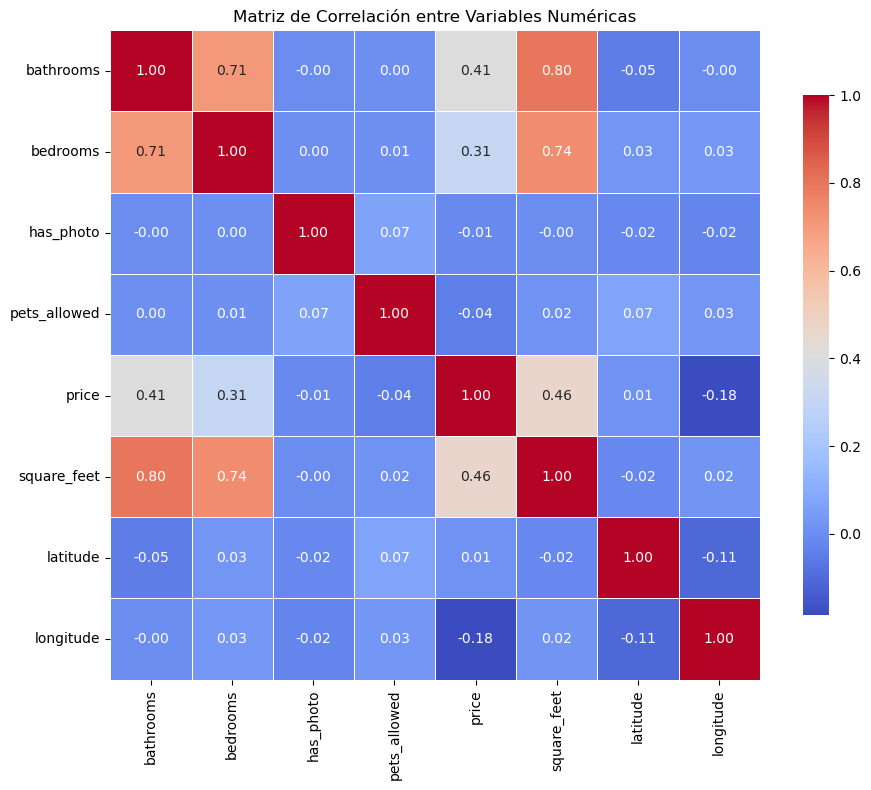

In [90]:
"""
Muestra un heatmap simple de correlación entre variables numéricas del DataFrame.
"""
# Seleccionar solo columnas numéricas
df_numeric = df.select_dtypes(include=[np.number])

# Calcular la matriz de correlación
corr_matrix = df_numeric.corr()

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Crear el heatmap
sns.heatmap(
    corr_matrix,
    annot=True,          # Mostrar los valores dentro de las celdas
    fmt=".2f",           # Formato de los números
    cmap="coolwarm",     # Paleta de colores
    square=True,         # Cuadrado en cada celda
    linewidths=0.5,      # Líneas entre celdas
    cbar_kws={"shrink": 0.8}  # Ajuste de la barra de colores
)

plt.title("Matriz de Correlación entre Variables Numéricas")
plt.tight_layout()
plt.show()

Para completar ciudad y estados vamos a usar la herramienta geopy para reverse geocoding con latitud y longitud

In [91]:
city_missing = df['cityname'].isnull().sum()
state_missing = df['state'].isnull().sum()

if city_missing > 0 or state_missing > 0:
    print(f"   Registros a procesar: {max(city_missing, state_missing)}")

    try:
        from geopy.geocoders import Nominatim
        from geopy.exc import GeocoderTimedOut, GeocoderServiceError
        import time
    except ImportError:
        print("   ERROR: geopy no instalado. Imputando con moda...")
        if city_missing > 0:
            mode_city = df['cityname'].mode()[0] if not df['cityname'].mode().empty else 'Unknown'
            df['cityname'].fillna(mode_city, inplace=True)
        if state_missing > 0:
            mode_state = df['state'].mode()[0] if not df['state'].mode().empty else 'Unknown'
            df['state'].fillna(mode_state, inplace=True)
    else:
        geolocator = Nominatim(user_agent="apartment_rental_prediction_2025")

        def reverse_geocode(lat, lon, max_retries=3):
            for attempt in range(max_retries):
                try:
                    time.sleep(1.1)
                    location = geolocator.reverse(f"{lat}, {lon}", language='en', timeout=10)

                    if location and location.raw.get('address'):
                        address = location.raw['address']
                        city = (address.get('city') or address.get('town') or
                               address.get('village') or address.get('municipality') or
                               address.get('county'))
                        state = address.get('state')
                        return {'city': city, 'state': state}
                    return None
                except (GeocoderTimedOut, GeocoderServiceError):
                    if attempt < max_retries - 1:
                        time.sleep(2)
                        continue
                    return None
                except:
                    return None
            return None

        needs_geocoding = (df['cityname'].isnull() | df['state'].isnull())
        total_to_process = needs_geocoding.sum()

        geocoded = 0
        failed = 0

        for idx in df[needs_geocoding].index:
            row = df.loc[idx]
            if pd.notna(row['latitude']) and pd.notna(row['longitude']):
                result = reverse_geocode(row['latitude'], row['longitude'])

                if result:
                    if result['city'] and pd.isna(df.at[idx, 'cityname']):
                        df.at[idx, 'cityname'] = result['city']
                    if result['state'] and pd.isna(df.at[idx, 'state']):
                        df.at[idx, 'state'] = result['state']
                    geocoded += 1
                else:
                    failed += 1

                if (geocoded + failed) % 20 == 0:
                    print(f"   Progreso: {geocoded + failed}/{total_to_process}")

        print(f"   Geocoding: {geocoded} exitosos, {failed} fallidos")

        if df['cityname'].isnull().sum() > 0 or df['state'].isnull().sum() > 0:
            if df['cityname'].isnull().sum() > 0:
                mode_city = df['cityname'].mode()[0] if not df['cityname'].mode().empty else 'Unknown'
                df['cityname'].fillna(mode_city, inplace=True)
            if df['state'].isnull().sum() > 0:
                mode_state = df['state'].mode()[0] if not df['state'].mode().empty else 'Unknown'
                df['state'].fillna(mode_state, inplace=True)
else:
    print(f"   No hay valores faltantes")

   Registros a procesar: 67
   Progreso: 20/67
   Progreso: 40/67
   Progreso: 60/67
   Geocoding: 67 exitosos, 0 fallidos


In [95]:

def clustering_geografico_avanzado(df, n_clusters=None):
    """
    Realiza clustering geográfico usando múltiples algoritmos y selecciona el mejor.
    """
    geo_data = df[['latitude', 'longitude']].dropna()

    # Normalizar coordenadas
    scaler = StandardScaler()
    geo_scaled = scaler.fit_transform(geo_data)

    # Si no se especifica n_clusters, encontrar el óptimo
    if n_clusters is None:
        silhouette_scores = []
        k_range = range(3, min(15, len(geo_data)//10))

        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(geo_scaled)
            score = silhouette_score(geo_scaled, labels)
            silhouette_scores.append(score)

        # Seleccionar k con mejor silhouette score
        n_clusters = k_range[np.argmax(silhouette_scores)]
        print(f"Número óptimo de clusters: {n_clusters} (Silhouette Score: {max(silhouette_scores):.3f})")

    # Aplicar K-Means con el número óptimo
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    geo_data['neighborhood_cluster'] = kmeans.fit_predict(geo_scaled)

    # También probar DBSCAN para detectar zonas de alta densidad
    dbscan = DBSCAN(eps=0.01, min_samples=5)
    geo_data['density_cluster'] = dbscan.fit_predict(geo_scaled)

    # Merge con dataframe original
    df = df.merge(geo_data[['neighborhood_cluster', 'density_cluster']],
                  left_index=True, right_index=True, how='left')

    # Calcular estadísticas por cluster
    if 'neighborhood_cluster' in df.columns:
        cluster_stats = df.groupby('neighborhood_cluster').agg({
            'price': ['mean', 'median', 'std'],
            'square_feet': 'mean',
        }).round(2)

        print("\nEstadísticas por Cluster:")
        print(cluster_stats)

    return df
clustering_geografico_avanzado(df)

Número óptimo de clusters: 14 (Silhouette Score: 0.595)

Estadísticas por Cluster:
                        price                  square_feet
                         mean  median      std        mean
neighborhood_cluster                                      
0                     1235.46  1050.0   709.93      935.34
1                     2351.62  1895.0  2443.20      991.86
2                     1521.97  1300.0  1045.53     1055.90
3                     1173.71  1100.0   448.15      978.56
4                     1706.96  1588.0   720.71      931.44
5                     1734.38  1585.0   794.03      905.30
6                     1120.74  1029.5   356.10      782.12
7                     1244.72  1199.0   458.73     1118.14
8                     1046.64   895.0   543.88      909.23
9                     1011.64   917.5   270.30      726.16
10                    1146.46  1039.0   527.91      920.34
11                    3689.08  2850.0  2616.22     1401.00
12                    1330.17  1

,title,body,amenities,bathrooms,bedrooms,has_photo,pets_allowed,price,price_type,square_feet,...,state,latitude,longitude,price_per_sqft,price_per_bedroom,price_per_bathroom,total_rooms,sqft_per_room,neighborhood_cluster,density_cluster
2,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,1.0,0,1390,Monthly,107,...,VA,38.8910,-77.0816,12.990654,1390.000000,926.666667,1.0,53.500000,5,0
3,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,1.0,0,925,Monthly,116,...,WA,47.6160,-122.3275,7.974138,925.000000,616.666667,1.0,58.000000,4,1
5,0 BR in New York NY 10019,**RARE GEM WITH PRIVATE OUTDOOR TERRACE****AVA...,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,1.0,0,2475,Monthly,130,...,NY,40.7629,-73.9885,19.038462,2475.000000,1650.000000,1.0,65.000000,5,2
8,Studio apartment 333 Hyde St,"This unit is located at 333 Hyde St, San Franc...",Refrigerator,1.0,0.0,1.0,0,1495,Monthly,138,...,CA,37.7599,-122.4379,10.833333,1495.000000,996.666667,1.0,69.000000,13,3
14,Studio apartment 57 Taylor Street,"This unit is located at 57 Taylor Street, San ...",Refrigerator,1.0,0.0,1.0,0,1695,Monthly,190,...,CA,37.7599,-122.4379,8.921053,1695.000000,1130.000000,1.0,95.000000,13,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,Six BR 2536 W Canyon Ridge Rd.,This unit is located at 2536 W Canyon Ridge Rd...,NaN,4.0,6.0,1.0,0,3000,Monthly,5921,...,UT,37.0835,-113.5823,0.506671,428.571429,666.666667,10.0,538.272727,13,126
9995,Five BR 5407 Abbott Place - Abbott,This unit is located at 5407 Abbott Place - Ab...,NaN,4.0,5.0,1.0,0,6000,Monthly,6300,...,MN,44.9000,-93.3233,0.952381,1000.000000,1333.333333,9.0,630.000000,10,60
9996,Six BR 256 Las Entradas,"This unit is located at 256 Las Entradas, Mont...",NaN,8.0,6.0,1.0,0,25000,Monthly,8716,...,CA,34.4331,-119.6331,2.868288,3571.428571,2941.176471,14.0,581.066667,1,218
9997,Six BR 9908 Bentcross Drive,"This unit is located at 9908 Bentcross Drive, ...",NaN,8.5,6.0,1.0,0,11000,Monthly,11318,...,MD,39.0287,-77.2409,0.971903,1571.428571,1222.222222,14.5,730.193548,5,0


In [96]:
if 'neighborhood_cluster' in df.columns:
    # Precio mediano del barrio
    neighborhood_stats = df.groupby('neighborhood_cluster')['price'].agg(['median', 'mean', 'std'])
    neighborhood_stats.columns = ['neighborhood_median_price', 'neighborhood_mean_price', 'neighborhood_std_price']
    df = df.merge(neighborhood_stats, left_on='neighborhood_cluster', right_index=True, how='left')

    # Ratio del precio respecto al barrio
    df['price_to_neighborhood_median'] = df['price'] / df['neighborhood_median_price']
    df['price_deviation_from_neighborhood'] = (df['price'] - df['neighborhood_mean_price']) / df['neighborhood_std_price']

In [97]:
# Ratios y métricas derivadas
df['price_per_sqft'] = df['price'] / df['square_feet']
df['price_per_bedroom'] = df['price'] / (df['bedrooms'] + 1)
df['price_per_bathroom'] = df['price'] / (df['bathrooms'] + 0.5)
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['sqft_per_room'] = df['square_feet'] / (df['total_rooms'] + 1)

Agregar restriccion que si en el title no dice studio no puede tener 0 cuartos


In [98]:
precio_max_razonable = df['price'].quantile(0.995)
precio_min_razonable = df['price'].quantile(0.005)
df_clean = df[(df['price'] >= precio_min_razonable) & (df['price'] <= precio_max_razonable)].copy()

In [102]:
# Preparar datos para modelado
# Identificar columnas numéricas y categóricas
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Eliminar columnas de texto largas y la variable objetivo
columnas_excluir = ['price', 'body', 'title', 'address']
numeric_features = [col for col in numeric_features if col not in columnas_excluir]
categorical_features = [col for col in categorical_features if col not in columnas_excluir]

print(f"✅ Features numéricos: {len(numeric_features)}")
print(f"✅ Features categóricos: {len(categorical_features)}")

# Encoding de variables categóricas
label_encoders = {}
for col in categorical_features:
    if col in df_clean.columns:
        le = LabelEncoder()
        df_clean[col + '_encoded'] = le.fit_transform(df_clean[col].fillna('unknown').astype(str))
        label_encoders[col] = le
        numeric_features.append(col + '_encoded')

# Selección de características con mutual information
if len(numeric_features) > 20:
    X_temp = df_clean[numeric_features].fillna(0)
    y_temp = df_clean['price']

    selector = SelectKBest(score_func=mutual_info_regression, k=min(20, len(numeric_features)))
    selector.fit(X_temp, y_temp)

    # Obtener las mejores características
    feature_scores = pd.DataFrame({
        'feature': numeric_features,
        'score': selector.scores_
    }).sort_values('score', ascending=False)

    print("\n📈 Top 10 características más importantes:")
    print(feature_scores.head(10))

    # Seleccionar las mejores
    best_features = feature_scores.head(20)['feature'].tolist()
else:
    best_features = numeric_features


✅ Features numéricos: 12
✅ Features categóricos: 4


In [104]:

# Crear conjuntos X e y
X = df_clean[best_features].fillna(0)
y = df_clean['price']

print(f"✅ Dimensiones finales de X: {X.shape}")
print(f"✅ Dimensión de y: {y.shape}")

# División estratificada
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f"\n📊 División de datos:")
print(f"   • Entrenamiento: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   • Validación: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   • Prueba: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Escalado robusto
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

✅ Dimensiones finales de X: (9856, 16)
✅ Dimensión de y: (9856,)

📊 División de datos:
   • Entrenamiento: 6902 (70.0%)
   • Validación: 1475 (15.0%)
   • Prueba: 1479 (15.0%)


In [108]:

# Definir modelos
modelos = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.1, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.1, random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
}

# Entrenar y evaluar modelos
resultados = {}

for nombre, modelo in modelos.items():
    print(f"\n🔄 Entrenando {nombre}...")

    # Entrenar
    modelo.fit(X_train_scaled, y_train)

    # Predicciones
    y_train_pred = modelo.predict(X_train_scaled)
    y_val_pred = modelo.predict(X_val_scaled)

    # Métricas
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)

    resultados[nombre] = {
        'modelo': modelo,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_r2': train_r2,
        'val_r2': val_r2
    }

    print(f"   RMSE: Train={train_rmse:.2f} | Val={val_rmse:.2f}")
    print(f"   R²:   Train={train_r2:.4f} | Val={val_r2:.4f}")



🔄 Entrenando Linear Regression...
   RMSE: Train=182.49 | Val=188.85
   R²:   Train=0.9420 | Val=0.9335

🔄 Entrenando Ridge...
   RMSE: Train=182.50 | Val=188.82
   R²:   Train=0.9420 | Val=0.9335

🔄 Entrenando Lasso...
   RMSE: Train=182.52 | Val=188.75
   R²:   Train=0.9420 | Val=0.9336

🔄 Entrenando ElasticNet...
   RMSE: Train=201.20 | Val=201.81
   R²:   Train=0.9296 | Val=0.9240

🔄 Entrenando Decision Tree...
   RMSE: Train=7.35 | Val=59.53
   R²:   Train=0.9999 | Val=0.9934

🔄 Entrenando Random Forest...
   RMSE: Train=17.85 | Val=55.80
   R²:   Train=0.9994 | Val=0.9942

🔄 Entrenando Gradient Boosting...
   RMSE: Train=9.41 | Val=37.42
   R²:   Train=0.9998 | Val=0.9974

🔄 Entrenando XGBoost...
   RMSE: Train=10.39 | Val=51.57
   R²:   Train=0.9998 | Val=0.9950


In [109]:
# Crear DataFrame con resultados
resultados_df = pd.DataFrame({
    nombre: {
        'RMSE_Train': res['train_rmse'],
        'RMSE_Val': res['val_rmse'],
        'R²_Train': res['train_r2'],
        'R²_Val': res['val_r2']
    }
    for nombre, res in resultados.items()
}).T

resultados_df = resultados_df.sort_values('R²_Val', ascending=False)
print("\n🏆 RANKING DE MODELOS (por R² de validación):")
print(resultados_df.round(4))

# Seleccionar el mejor modelo
mejor_modelo_nombre = resultados_df.index[0]
mejor_modelo = resultados[mejor_modelo_nombre]['modelo']

print(f"\n🥇 Mejor modelo: {mejor_modelo_nombre}")
print(f"   • R² de validación: {resultados_df.loc[mejor_modelo_nombre, 'R²_Val']:.4f}")
print(f"   • RMSE de validación: ${resultados_df.loc[mejor_modelo_nombre, 'RMSE_Val']:.2f}")


🏆 RANKING DE MODELOS (por R² de validación):
                   RMSE_Train  RMSE_Val  R²_Train  R²_Val
Gradient Boosting      9.4103   37.4225    0.9998  0.9974
XGBoost               10.3902   51.5727    0.9998  0.9950
Random Forest         17.8466   55.7963    0.9994  0.9942
Decision Tree          7.3494   59.5289    0.9999  0.9934
Lasso                182.5189  188.7472    0.9420  0.9336
Ridge                182.4992  188.8170    0.9420  0.9335
Linear Regression    182.4929  188.8478    0.9420  0.9335
ElasticNet           201.1972  201.8050    0.9296  0.9240

🥇 Mejor modelo: Gradient Boosting
   • R² de validación: 0.9974
   • RMSE de validación: $37.42


In [110]:
# Predicciones finales
y_test_pred = mejor_modelo.predict(X_test_scaled)

# Métricas finales
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)

print(f"\n📊 MÉTRICAS FINALES - {mejor_modelo_nombre}:")
print(f"   • R² Score: {test_r2:.4f}")
print(f"   • RMSE: ${test_rmse:.2f}")
print(f"   • MAE: ${test_mae:.2f}")
print(f"   • MAPE: {test_mape:.2%}")



📊 MÉTRICAS FINALES - Gradient Boosting:
   • R² Score: 0.9938
   • RMSE: $63.90
   • MAE: $12.62
   • MAPE: 0.63%



IMPORTANCIA DE CARACTERÍSTICAS

📊 Top 10 características más importantes:
               feature  importance
9   price_per_bathroom    0.725819
0            bathrooms    0.270246
10         total_rooms    0.002267
4          square_feet    0.000875
8    price_per_bedroom    0.000511
12   amenities_encoded    0.000103
11       sqft_per_room    0.000049
14    cityname_encoded    0.000047
7       price_per_sqft    0.000033
6            longitude    0.000020


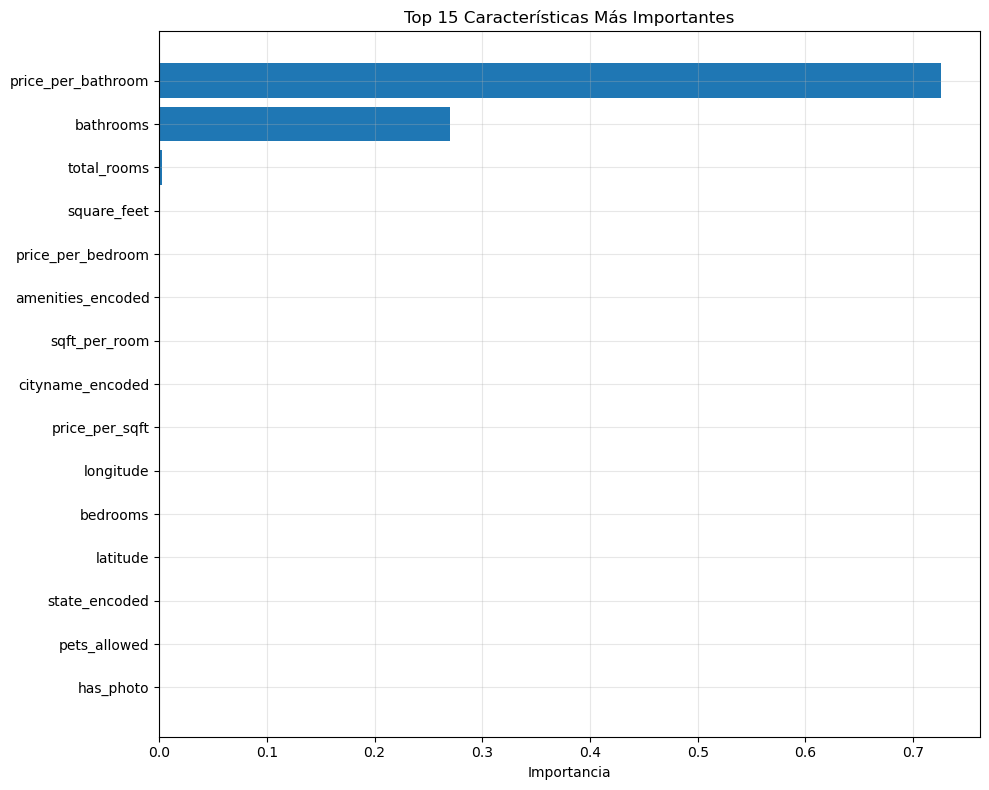

In [111]:
if hasattr(mejor_modelo, 'feature_importances_'):
    print("\n" + "="*80)
    print("IMPORTANCIA DE CARACTERÍSTICAS")
    print("="*80)

    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': mejor_modelo.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\n📊 Top 10 características más importantes:")
    print(feature_importance.head(10))

    # Visualización
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importancia')
    plt.title('Top 15 Características Más Importantes')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

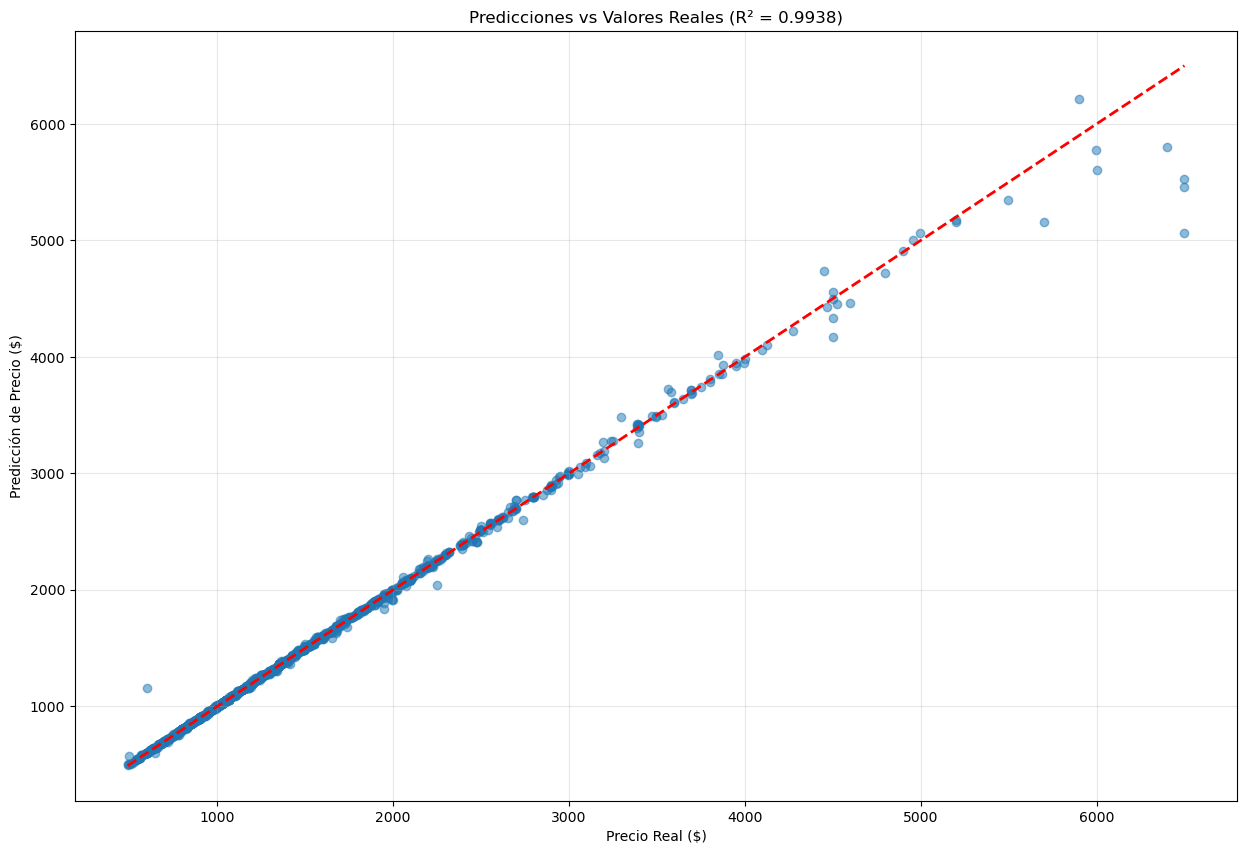

In [123]:
fig, ax = plt.subplots(figsize=(15, 10))

ax.scatter(y_test, y_test_pred, alpha=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Precio Real ($)')
ax.set_ylabel('Predicción de Precio ($)')
ax.set_title(f'Predicciones vs Valores Reales (R² = {test_r2:.4f})')
ax.grid(True, alpha=0.3)

plt.show()

In [113]:
import pickle
# Guardar el mejor modelo
with open('mejor_modelo_alquiler.pkl', 'wb') as f:
    pickle.dump(mejor_modelo, f)
print("✅ Modelo guardado: mejor_modelo_alquiler.pkl")

# Guardar el scaler
with open('scaler_alquiler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler guardado: scaler_alquiler.pkl")

# Guardar los encoders
with open('label_encoders_alquiler.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("✅ Encoders guardados: label_encoders_alquiler.pkl")

# Guardar resultados
resultados_df.to_csv('resultados_modelos.csv')
print("✅ Resultados guardados: resultados_modelos.csv")

# Guardar características importantes
if hasattr(mejor_modelo, 'feature_importances_'):
    feature_importance.to_csv('importancia_caracteristicas.csv', index=False)
    print("✅ Importancia de características guardada: importancia_caracteristicas.csv")

✅ Modelo guardado: mejor_modelo_alquiler.pkl
✅ Scaler guardado: scaler_alquiler.pkl
✅ Encoders guardados: label_encoders_alquiler.pkl
✅ Resultados guardados: resultados_modelos.csv
✅ Importancia de características guardada: importancia_caracteristicas.csv
